In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_dual_heatmaps(array1, array2, array3, 
                      title1='Heatmap 1', title2='Heatmap 2', title3='Heatmap 3',
                      cmap='viridis', figsize=(18, 6),
                      vmin=None, vmax=None,
                      colorbar=True, idx=0, text="training"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)

    if vmin is None:
        vmin = min(np.nanmin(array1), np.nanmin(array2), np.nanmin(array3))
    if vmax is None:
        vmax = max(np.nanmax(array1), np.nanmax(array2), np.nanmin(array3))

    im1 = ax1.imshow(array1, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    ax1.set_title(title1)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    if colorbar:
        fig.colorbar(im1, ax=ax1, label='Value')

    im2 = ax2.imshow(array2, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    ax2.set_title(title2)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    if colorbar:
        fig.colorbar(im2, ax=ax2, label='Value')

    rmse = torch.mean((array2 - array3)**2).sqrt().item()

    im3 = ax3.imshow(array3, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    ax3.set_title(f"{title3} rmse={rmse:4f}")
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    if colorbar:
        fig.colorbar(im3, ax=ax3, label='Value')
    
    plt.suptitle(f"Navier-Stokes Vorticity Transport idx={idx} ({text})")
    plt.tight_layout()
    plt.show()

In [34]:
import os
import sys
from pathlib import Path

notebook_path = Path(os.getcwd())
project_root = notebook_path.parent.parent.parent
sys.path.append(str(project_root))

import numpy as np
from models.FNO2d import FNO2d
from training_models.utilities3 import UnitGaussianNormalizer

def draw_plots(frame):
    data_test = torch.load(f'../../../../datasets/2D/NS/input_frame_{frame}/NS_data_zongyi_test.pt', weights_only=False)
    data_train = torch.load(f'../../../../datasets/2D/NS/input_frame_{frame}/NS_data_zongyi_train.pt', weights_only=False)
    model_instance = FNO2d(
        modes1=12, 
        modes2=12, 
        width=16
    )
    state_dict = torch.load(
        f'input_frame_{frame}/NS_2d_FNO_model_trainedby_NS_data_zongyi_train.pth',
        map_location=torch.device('cpu')
    )
    model_instance.load_state_dict(state_dict)
    model_instance.eval() 

    x_normalizer = UnitGaussianNormalizer(data_train["x"].unsqueeze(-1))
    y_normalizer = UnitGaussianNormalizer(data_train["y"].unsqueeze(-1))

    with torch.no_grad():
        for idx in range(2):
            input_ = data_train["x"][idx]
            PDE_output = data_train["y"][idx]
            FNO_output = y_normalizer.decode(model_instance(x_normalizer.encode(input_.unsqueeze(0).unsqueeze(-1)))).squeeze(0).squeeze(-1)
            plot_dual_heatmaps(input_, PDE_output, FNO_output, title1='input', title2='PDE output', title3='FNO output', idx=idx+1, text=f"input=frame{frame} modes12 width16 train")
        for idx in range(2):
            input_ = data_test["x"][idx]
            PDE_output = data_test["y"][idx]
            FNO_output = y_normalizer.decode(model_instance(x_normalizer.encode(input_.unsqueeze(0).unsqueeze(-1)))).squeeze(0).squeeze(-1)
            plot_dual_heatmaps(input_, PDE_output, FNO_output, title1='input', title2='PDE output', title3='FNO output', idx=idx+1, text=f"input=frame{frame} modes12 width16 test")

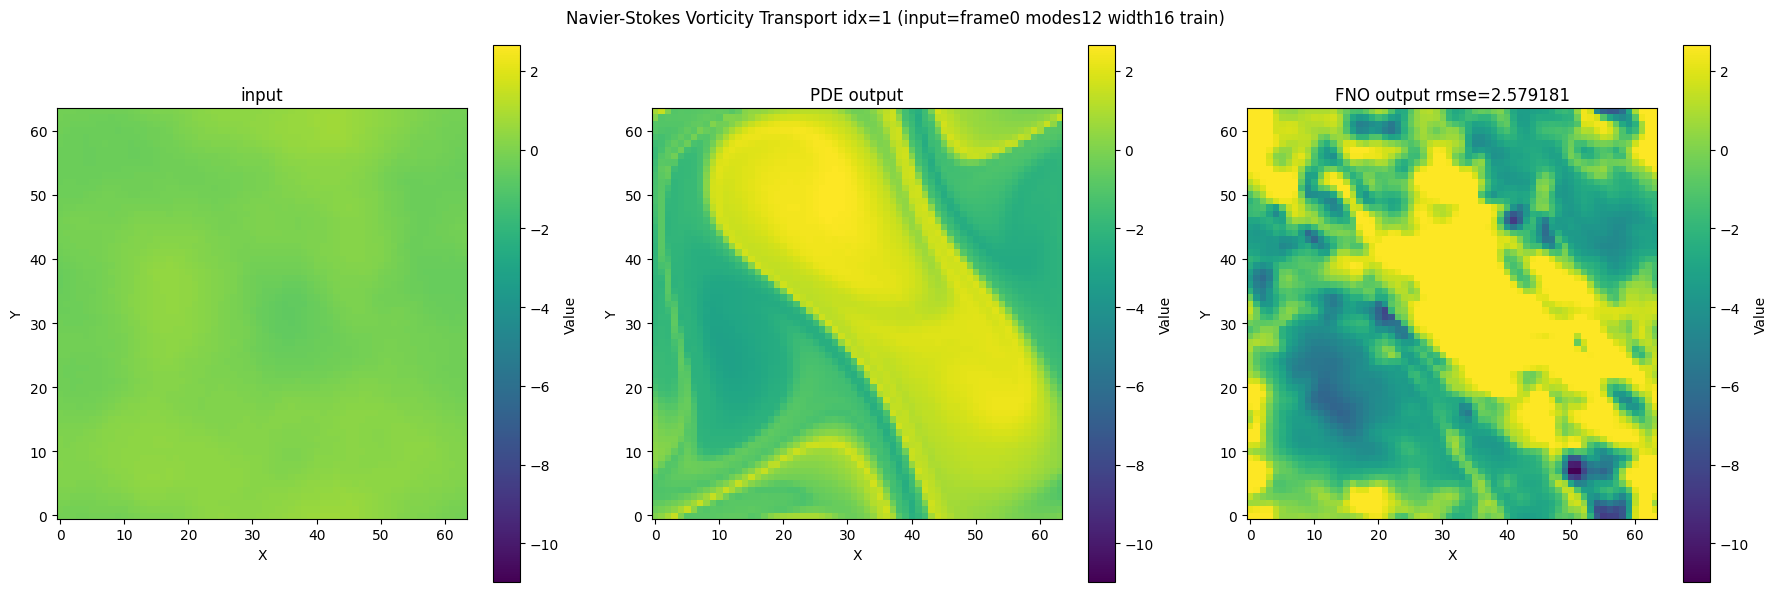

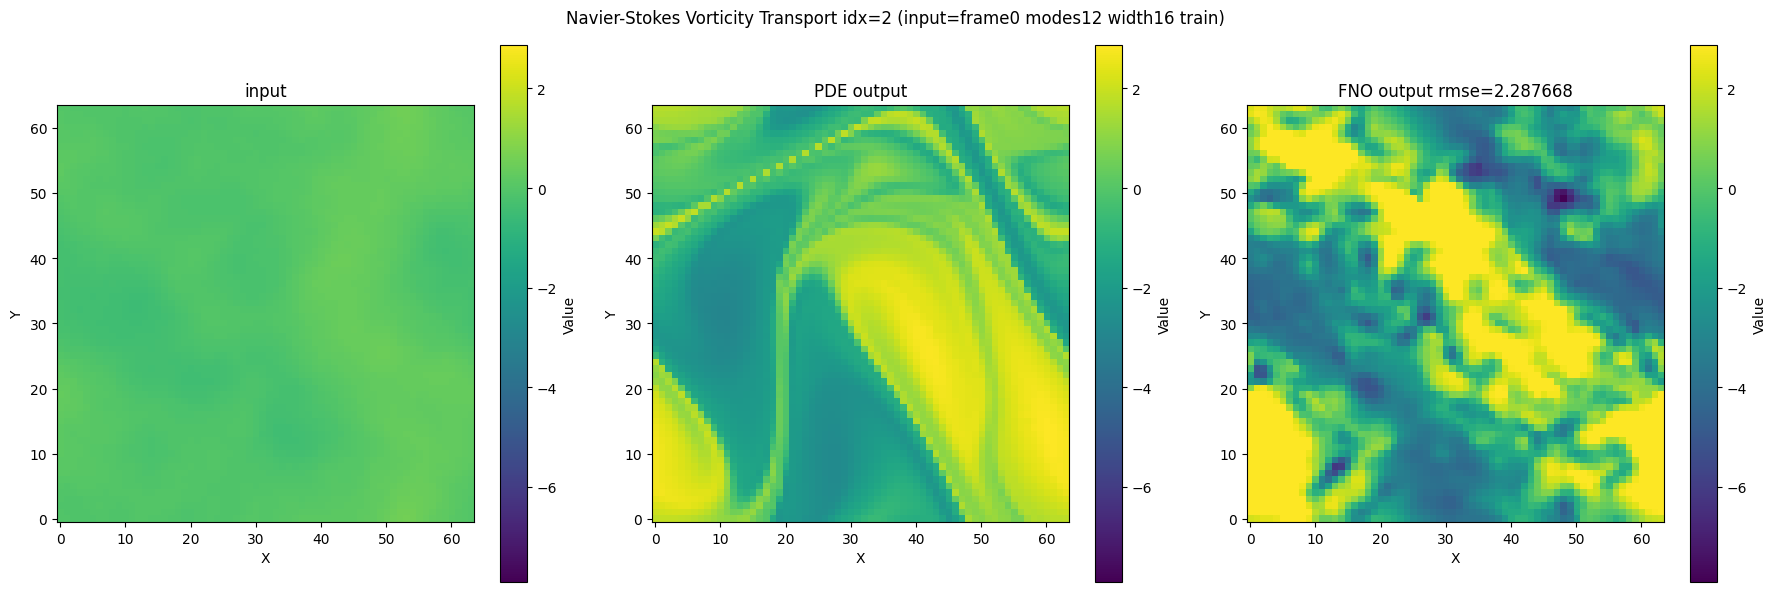

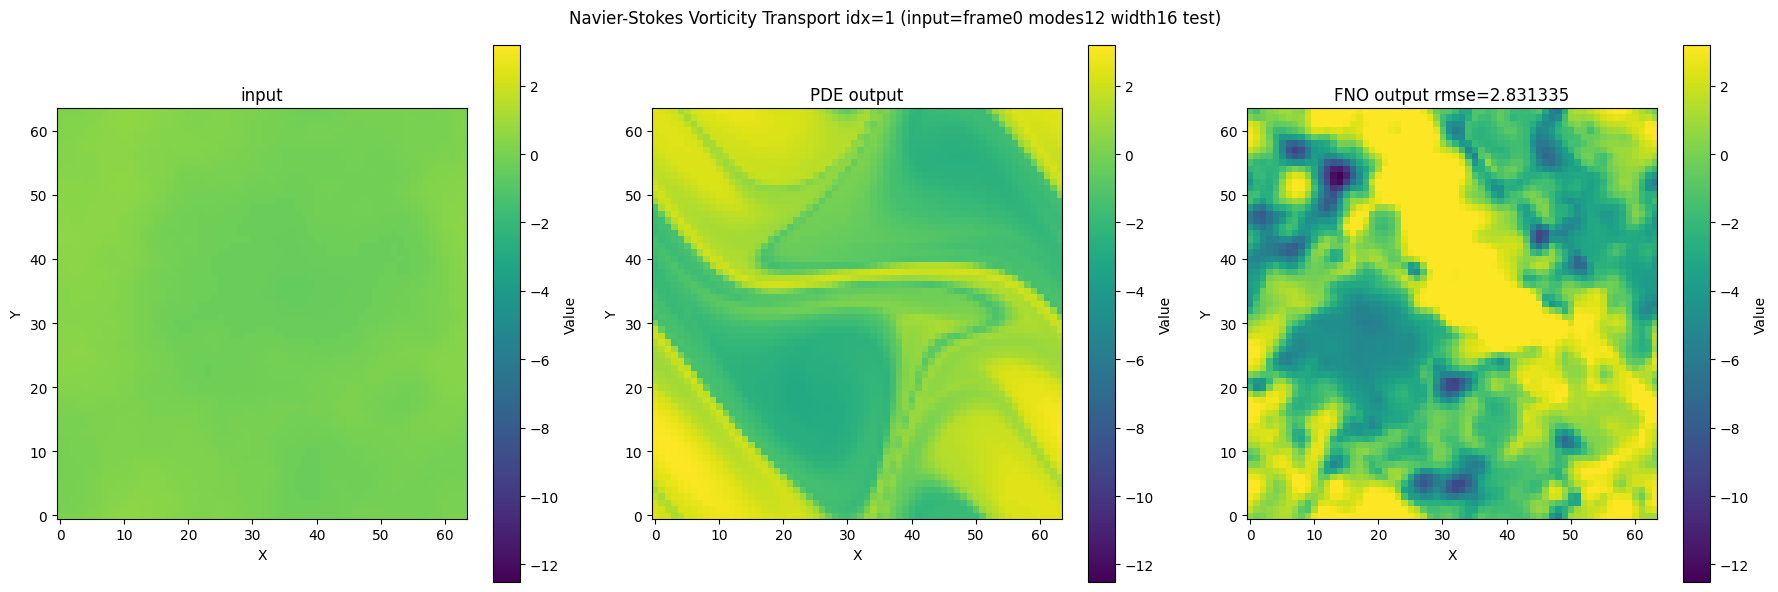

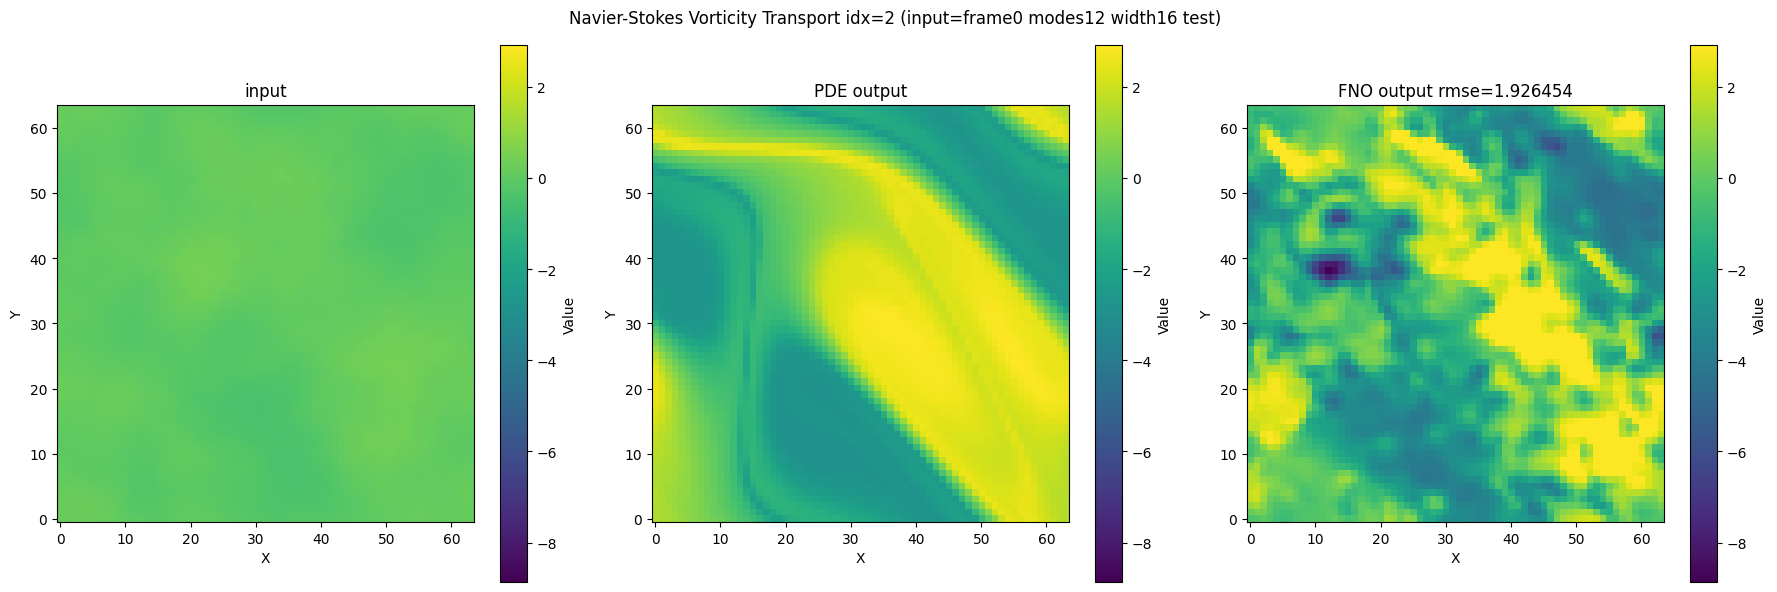

In [35]:
draw_plots(frame=0)